In [1]:
from dotenv import load_dotenv
import os 


WANDB_API_KEY = os.getenv("WANDB_API_KEY")


# Load dataset

In [2]:
from torchvision import transforms, datasets
from torch.utils.data import Dataset
from PIL import Image
import torch 
import os 


class FruitDetectionDataset(Dataset):

    def __init__(self, root_dir: str, img_dir, annotations_path: str, transform=None):
        self.root_dir = root_dir
        self.img_dir = img_dir
        self.annotations_path = annotations_path
        self.transform = transform
    


        self.image_ids = [f for f in os.listdir(os.path.join(self.root_dir, self.img_dir)) if f.endswith('.jpg')]  
        


    def get_annotations(self, image_id: str):

        annotator_path = os.path.join(self.root_dir, self.annotations_path, image_id.replace('.jpg', '.txt'))

        if os.path.exists(annotator_path):
            with open(annotator_path, 'r') as f:
                annotations = f.readlines()
            
            # Parse the annotations
            boxes = []
            labels = []
            for line in annotations:
                parts = line.strip().split()
                label = int(parts[0])
                x1, y1, x2, y2 = map(float, parts[1:])
                boxes.append([x1, y1, x2, y2])
                labels.append(label)
            
            return boxes, labels
        

        return [], []  
    
    def __len__(self):
        return len(self.image_ids)
    

    def __getitem__(self, idx): 
        
        image_id = self.image_ids[idx]

        boxes, labels = self.get_annotations(image_id)
        image_path = os.path.join(self.root_dir, self.img_dir, image_id)

        img = Image.open(image_path).convert("RGB")


        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)


        target = {
            "boxes": boxes,
            "labels": labels
        }   

        if self.transform:
            img = self.transform(img)



        return img, target




In [3]:
train_dataset = FruitDetectionDataset( 
    root_dir='data/Dataset',
    img_dir='Train/images',
    annotations_path='Train/labels',
    transform = transforms.Compose([
        transforms.PILToTensor(),
        transforms.ConvertImageDtype(torch.float),
    ]),
) 

In [4]:
train_dataset[0]

(tensor([[[0.5137, 0.5176, 0.5294,  ..., 0.8824, 0.8667, 0.8627],
          [0.3608, 0.3686, 0.3804,  ..., 0.9098, 0.9059, 0.9059],
          [0.3020, 0.3020, 0.3098,  ..., 0.8157, 0.8157, 0.8157],
          ...,
          [0.0431, 0.0431, 0.0431,  ..., 0.9686, 0.9451, 0.9255],
          [0.0431, 0.0431, 0.0431,  ..., 0.9529, 0.9294, 0.9098],
          [0.0431, 0.0431, 0.0431,  ..., 0.9176, 0.9020, 0.8824]],
 
         [[0.4157, 0.4196, 0.4314,  ..., 0.8235, 0.8235, 0.8235],
          [0.2706, 0.2784, 0.2902,  ..., 0.8431, 0.8549, 0.8588],
          [0.2235, 0.2235, 0.2314,  ..., 0.7412, 0.7569, 0.7647],
          ...,
          [0.0431, 0.0431, 0.0431,  ..., 0.9765, 0.9529, 0.9333],
          [0.0431, 0.0431, 0.0431,  ..., 0.9608, 0.9373, 0.9176],
          [0.0431, 0.0431, 0.0431,  ..., 0.9255, 0.9098, 0.8902]],
 
         [[0.2941, 0.2980, 0.3098,  ..., 0.6000, 0.6118, 0.6157],
          [0.1451, 0.1529, 0.1647,  ..., 0.6235, 0.6471, 0.6549],
          [0.0941, 0.0941, 0.1020,  ...,

In [5]:
from torchvision.utils import draw_bounding_boxes
import matplotlib.pyplot as plt


def show_image_with_boxes(idx):

    img, target = train_dataset[idx]
    boxes = target['boxes']
    labels = target['labels']
    label_strings = [str(label.item()) for label in labels]
    # Draw bounding boxes on the image
    img_with_boxes = draw_bounding_boxes(img, boxes, labels=label_strings, colors="red", width=3)

    # Convert to numpy array for plotting
    img_with_boxes = img_with_boxes.permute(1, 2, 0).numpy()

    plt.figure(figsize=(10, 10))
    plt.imshow(img_with_boxes)
    plt.axis('off')
    plt.show()



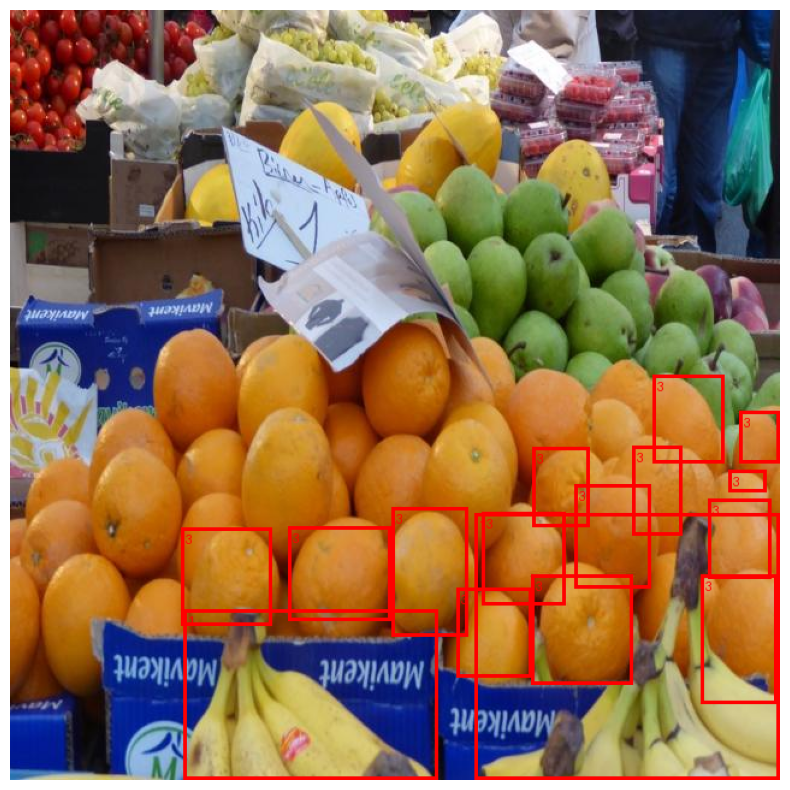

In [6]:
show_image_with_boxes(2)

In [7]:
_, target = train_dataset[2]

print(target['boxes'])

print(target['labels'])


print(f"len of idx 2: {len(target['boxes'])}")
print(f"len of idx 2: {len(target['labels'])}")

tensor([[144.2500, 498.7500, 355.7500, 639.2500],
        [386.5000, 418.7500, 639.5000, 639.2500],
        [433.1250, 469.8750, 517.8750, 560.1250],
        [142.5000, 430.0000, 217.5000, 511.0000],
        [231.7500, 429.7500, 316.2500, 507.2500],
        [317.8750, 413.7500, 380.1250, 520.2500],
        [371.7500, 480.0000, 433.2500, 554.0000],
        [392.0000, 417.2500, 461.0000, 494.7500],
        [434.0000, 363.2500, 481.0000, 429.7500],
        [469.7500, 394.7500, 532.2500, 480.2500],
        [517.5000, 362.0000, 558.5000, 436.0000],
        [534.0000, 303.7500, 593.0000, 376.2500],
        [574.5000, 469.0000, 637.5000, 576.0000],
        [580.7500, 406.5000, 632.2500, 472.5000],
        [597.7500, 382.0000, 628.2500, 400.0000],
        [606.1250, 333.8750, 639.8750, 376.1250]])
tensor([1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])
len of idx 2: 16
len of idx 2: 16


In [8]:
train_dataset.image_ids[2]

'f045d1819e2d038d_jpg.rf.a41d75df89689387f45a797159632d58.jpg'

# Datamodule

In [16]:
import lightning as pl 
from torch.utils.data import DataLoader, random_split


class FruitDatamodule(pl.LightningDataModule):
    def __init__(self, root_dir: str, img_dir: str, annotations_path: str, transforms = None, batch_size: int = 32, train_val_ratio: float = 0.9):
        super().__init__()
        self.root_dir = root_dir
        self.img_dir = img_dir
        self.annotations_path = annotations_path
        self.batch_size = batch_size

        self.transforms = transforms
        self.train_val_ratio = train_val_ratio

    def setup(self, stage=None):

        self.train_dataset = FruitDetectionDataset(
            root_dir=self.root_dir,
            img_dir=self.img_dir,
            annotations_path=self.annotations_path,
            transform=self.transforms
        )
        if stage == 'fit' or stage is None:

            train_size, val_size = int(len(self.train_dataset) * self.train_val_ratio), len(self.train_dataset) - int(len(self.train_dataset) * self.train_val_ratio)

            self.train_dataset, self.val_dataset = random_split(
                self.train_dataset,
                [train_size, val_size]
            )


        if stage == 'test' or stage is None:


            test_size = len(self.train_dataset) - int(len(self.train_dataset) * self.train_val_ratio)

            self.test_dataset = random_split(
                self.train_dataset,
                [test_size]
            )[0]
    
    @staticmethod
    def collate_fn(batch):
        return tuple(zip(*batch))

    def train_dataloader(self):
        return DataLoader( self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=4, collate_fn=self.collate_fn )


    def val_dataloader(self):
        return DataLoader( self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4, collate_fn=self.collate_fn )

    def test_dataloader(self):
        return DataLoader( self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4 , collate_fn=self.collate_fn )

In [10]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection import MeanAveragePrecision, IntersectionOverUnion
import torch.optim as optim 

class FruitDetectionModel(pl.LightningModule):
    def __init__(self, num_classes: int, learning_rate: float = 0.001):
        super().__init__()


        self.model = fasterrcnn_resnet50_fpn(pretrained=True)
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

        self.train_map = MeanAveragePrecision()
        self.val_map = MeanAveragePrecision()
        self.test_map = MeanAveragePrecision()


        self.train_iou = IntersectionOverUnion()
        self.val_iou = IntersectionOverUnion()
        self.test_iou = IntersectionOverUnion()


        self.learning_rate = learning_rate





    def forward(self, images, targets=None):
        return self.model(images, targets)


    def training_step(self, batch, batch_idx):
        images, targets = batch 

        images = list(image for image in images)
        targets = [{k: v for k, v in t.items()} for t in targets]


        loss_dict = self.model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        
        self.log('train/loss', losses.detach(), prog_bar=True, on_step=True, on_epoch=True)
        for k, v in loss_dict.items():
            self.log(f"train/{k}", v.detach(), on_step=True, on_epoch=True, prog_bar=True)


        if batch_idx % 50 == 0: 
            self.model.eval()
            with torch.no_grad():
                predictions = self.model(images)
            self.model.train()


            preds = [
                {
                    'boxes': pred['boxes'],
                    'scores': pred['scores'],
                    'labels': pred['labels']
                }
                for pred in predictions
            ]
            

            targets = [
                {
                    'boxes': target['boxes'],
                    'labels': target['labels']
                }
                for target in targets
            ]

            self.train_map.update(preds, targets)
            self.train_iou.update(preds, targets)

        return losses



    def on_train_epoch_end(self, outputs):
        map_score = self.train_map.compute()
        iou_score = self.train_iou.compute()

        self.log('train/mAP', map_score['map'], prog_bar=True)
        self.log('train/IoU', iou_score['iou'], prog_bar=True)
        self.log('train/mAP_50', map_score['map_50'], prog_bar=True)


        self.train_map.reset()
        self.train_iou.reset()


    def validation_step(self, batch, batch_idx):
        images, targets = batch 

        images = list(image for image in images)
        targets = [{k: v for k, v in t.items()} for t in targets]


        loss_dict = self.model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        
        self.log('val/loss', losses.detach(), prog_bar=True, on_step=True, on_epoch=True)
        for k, v in loss_dict.items():
            self.log(f"val/{k}", v.detach(), on_step=True, on_epoch=True, prog_bar=True)


        if batch_idx % 50 == 0: 
            self.model.eval()
            with torch.no_grad():
                predictions = self.model(images)
            self.model.train()


            preds = [
                {
                    'boxes': pred['boxes'],
                    'scores': pred['scores'],
                    'labels': pred['labels']
                }
                for pred in predictions
            ]
            

            targets = [
                {
                    'boxes': target['boxes'],
                    'labels': target['labels']
                }
                for target in targets
            ]

            self.val_map.update(preds, targets)
            self.val_iou.update(preds, targets)

        return losses

    def on_validation_epoch_end(self, outputs):
        map_score = self.val_map.compute()
        iou_score = self.val_iou.compute()

        self.log('val/mAP', map_score['map'], prog_bar=True)
        self.log('val/IoU', iou_score['iou'], prog_bar=True)
        self.log('val/mAP_50', map_score['map_50'], prog_bar=True)


        self.val_map.reset()
        self.val_iou.reset()


    def test_step(self, batch, batch_idx):

        images, targets = batch 

        images = list(image for image in images)
        targets = [{k: v for k, v in t.items()} for t in targets]


        loss_dict = self.model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        
        self.log('test/loss', losses.detach(), prog_bar=True, on_step=True, on_epoch=True)
        for k, v in loss_dict.items():
            self.log(f"test/{k}", v.detach(), on_step=True, on_epoch=True, prog_bar=True)


        if batch_idx % 50 == 0: 
            self.model.eval()
            with torch.no_grad():
                predictions = self.model(images)
            self.model.train()


            preds = [
                {
                    'boxes': pred['boxes'],
                    'scores': pred['scores'],
                    'labels': pred['labels']
                }
                for pred in predictions
            ]
            

            targets = [
                {
                    'boxes': target['boxes'],
                    'labels': target['labels']
                }
                for target in targets
            ]

            self.test_map.update(preds, targets)
            self.test_iou.update(preds, targets)

        return losses

    def on_test_epoch_end(self, outputs):

        map_score = self.test_map.compute()
        iou_score = self.test_iou.compute()

        self.log('test/mAP', map_score['map'], prog_bar=True)
        self.log('test/IoU', iou_score['iou'], prog_bar=True)
        self.log('test/mAP_50', map_score['map_50'], prog_bar=True)


        self.test_map.reset()
        self.test_iou.reset()



    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.learning_rate)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau( optimizer, mode='max', factor=0.5, patience=2)

        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val/loss',
                'interval': 'epoch',
                'frequency': 1
            }
        }





In [17]:
import wandb 
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

wandb.login(key=WANDB_API_KEY)



transform = transforms.Compose([
    transforms.PILToTensor(),
    transforms.ConvertImageDtype(torch.float),
])

datamodule = FruitDatamodule(
    root_dir='data/Dataset',
    img_dir='Train/images',
    annotations_path='Train/labels',
    transforms=transform,
    batch_size=32,
    train_val_ratio=0.9
)

model = FruitDetectionModel(
    num_classes=5,
    learning_rate=0.001
)



trainer = pl.Trainer(
    accelerator='gpu',
    devices=1,
    max_epochs=10,
    logger=WandbLogger(project="fruit-detection", name = "fast-rcnn-resnet50", log_model=True),
    callbacks=[
        ModelCheckpoint(monitor='val/loss', mode='min', save_top_k=1),
        EarlyStopping(monitor='val/loss', patience=3, mode='min')
    ],
    enable_progress_bar=True,
    profiler="simple",
)



wandb: WARNING Calling wandb.login() after wandb.init() has no effect.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [18]:
trainer.fit(model, datamodule)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                  | Params | Mode 
------------------------------------------------------------
0 | model     | FasterRCNN            | 41.3 M | train
1 | train_map | MeanAveragePrecision  | 0      | train
2 | val_map   | MeanAveragePrecision  | 0      | train
3 | test_map  | MeanAveragePrecision  | 0      | train
4 | train_iou | IntersectionOverUnion | 0      | train
5 | val_iou   | IntersectionOverUnion | 0      | train
6 | test_iou  | IntersectionOverUnion | 0      | train
------------------------------------------------------------
41.1 M    Trainable params
222 K     Non-trainable params
41.3 M    Total params
165.258   Total estimated model params size (MB)
195       Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.22 GiB. GPU 0 has a total capacity of 23.56 GiB of which 7.25 MiB is free. Process 557897 has 776.00 MiB memory in use. Process 1890720 has 726.00 MiB memory in use. Process 1898774 has 726.00 MiB memory in use. Process 1354341 has 376.00 MiB memory in use. Including non-PyTorch memory, this process has 5.73 GiB memory in use. Process 2017429 has 15.21 GiB memory in use. Of the allocated memory 4.50 GiB is allocated by PyTorch, and 957.31 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)